# First ML Model: Predicting Lipophilicity
earlier tried datasets and understood fungerprint work now willl combine both to train acutal model 

steps:
load dataset 
convert smiles to fingerprints
split into train and test sets
train linear regression baseline 
train random forest 
compare results using RMSE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

print("imports done")

imports done


In [3]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/Lipophilicity.csv"
df = pd.read_csv(url)
df.head()

,CMPD_CHEMBLID,exp,smiles
0,CHEMBL596271,3.54,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
1,CHEMBL1951080,-1.18,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...
2,CHEMBL1771,3.69,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl
3,CHEMBL234951,3.37,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...
4,CHEMBL565079,3.10,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...


In [2]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

print("imports done")

imports done


In [4]:
# Convert all SMILES to fingerprints
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

features = []
for smiles in df['smiles']:
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        fp = fp_gen.GetFingerprint(mol)
        arr = np.zeros((2048,))
        DataStructs.ConvertToNumpyArray(fp, arr)
        features.append(arr)
    else:
        features.append(np.zeros(2048))

X = np.array(features)
y = df['exp'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4200, 2048)
y shape: (4200,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3360
Testing samples: 840


we have split the train and test data
now we willl start with linear regression model 

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

# Calculate RMSE manually
lr_rmse = np.sqrt(np.mean((y_test - lr_preds) ** 2))
print("Linear Regression RMSE:", round(lr_rmse, 4))

Linear Regression RMSE: 1.2758


For drug discovery the difference between a good drug candidate and a bad one can be less than 1 unit.

Random Forest Model

Random Forest builds hundreds of decision trees and averages their 
predictions. It can capture non linear relationships between 
fingerprint bits and LogP something Linear Regression cannot do.

In [7]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(np.mean((y_test - rf_preds) ** 2))
print("Random Forest RMSE:", round(rf_rmse, 4))

Random Forest RMSE: 0.8252


Random Forest reduced error by ~35% over the linear baseline.

Linear Regression assumes LogP is a simple weighted sum of bits.
Random Forest captures non-linear combinations of structural patterns
which is closer to how molecular properties actually behave.

An RMSE of 0.82 means on average we are off by 0.82 LogP units.
The MoleculeNet benchmark reports ~0.65-0.70 for more advanced models.

Source: Wu et al., MoleculeNet (2018)
https://pmc.ncbi.nlm.nih.gov/articles/PMC5868307/


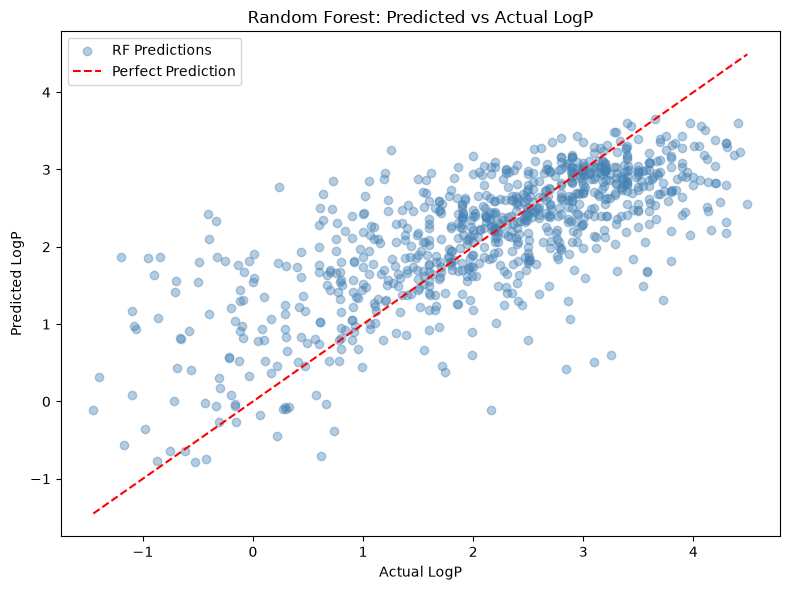

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.4, color='steelblue', label='RF Predictions')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel("Actual LogP")
plt.ylabel("Predicted LogP")
plt.title("Random Forest: Predicted vs Actual LogP")
plt.legend()
plt.tight_layout()
plt.show()

The red dashed line = perfect prediction. 
1. The middle range (LogP 1 to 3) fits well points cluster 
   tightly around the red line. This is where most training 
   data lives so the model learned it best.

2. At high LogP (above 3) points fall below the red line 
   the model underpredicts highly lipophilic molecules.

3. At low LogP (below 0) points fall above the red line 
   the model overpredicts very hydrophilic molecules.

regression to the mean : Random Forests average 
many predictions, which pulls extreme values toward the center.
It is a known limitation of tree-based models on sparse data.